# Mood Journal - Random Forest Emotion Classification

This notebook performs emotion classification on the GoEmotions dataset using Random Forest.

## Overview of Steps:
1. **Load the GoEmotions dataset** - Import and explore the data
2. **Perform EDA** - Visualize and understand the data distribution
3. **Train a Random Forest model** - Build and train the classifier
4. **Evaluate and display metrics** - Assess model performance
5. **Test with sample predictions** - Validate with example texts
6. **Save the trained model files** - Store model for future use

---
# STEP 1: Import Required Libraries

**Why this step is needed:**
- **pandas**: For data manipulation and analysis (loading CSV, DataFrame operations)
- **numpy**: For numerical computations and array operations
- **matplotlib & seaborn**: For creating visualizations and plots
- **sklearn**: For machine learning tools (TF-IDF, Random Forest, metrics)
- **warnings**: To suppress unnecessary warning messages for cleaner output

In [22]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning - Model and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

# Machine learning - Evaluation metrics
from sklearn.metrics import classification_report, accuracy_score, hamming_loss, f1_score

# Model saving
import joblib

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


---
# STEP 2: Load the GoEmotions Dataset

**Why this step is needed:**
- The GoEmotions dataset contains Reddit comments labeled with 27 different emotions
- We need to understand the data structure, size, and content before processing
- This helps identify any data quality issues (missing values, incorrect formats)
- Understanding the columns helps us determine which features to use for training

In [23]:
# Load the dataset from CSV file
df = pd.read_csv('GoEmotions.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (211225, 37)

Column Names:
['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [24]:
# Display first few rows to understand the data structure
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [25]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum().sum(), "total missing values")
missing_cols = df.isnull().sum()[df.isnull().sum() > 0]
if len(missing_cols) > 0:
    print(missing_cols)

Data Types:
text                        str
id                          str
author                      str
subreddit                   str
link_id                     str
parent_id                   str
created_utc             float64
rater_id                  int64
example_very_unclear       bool
admiration                int64
amusement                 int64
anger                     int64
annoyance                 int64
approval                  int64
caring                    int64
confusion                 int64
curiosity                 int64
desire                    int64
disappointment            int64
disapproval               int64
disgust                   int64
embarrassment             int64
excitement                int64
fear                      int64
gratitude                 int64
grief                     int64
joy                       int64
love                      int64
nervousness               int64
optimism                  int64
pride                     in

---
# STEP 3: Exploratory Data Analysis (EDA)

**Why this step is needed:**
- **Understand emotion distribution**: See which emotions are most/least common (helps identify class imbalance)
- **Analyze label counts**: Understand how many emotions each sample has (multi-label nature)
- **Text length analysis**: Understand the distribution of text lengths for preprocessing decisions
- **Correlation analysis**: See relationships between emotions (e.g., joy and excitement may correlate)
- **Data cleaning**: Remove unclear examples and samples with no labels for better model training

In [26]:
# Define the 27 emotion columns in the dataset
emotion_columns = ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
                   'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
                   'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
                   'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
                   'relief', 'remorse', 'sadness', 'surprise', 'neutral']

print(f"Number of emotion labels: {len(emotion_columns)}")
print("\nEmotion labels:", emotion_columns)

Number of emotion labels: 28

Emotion labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


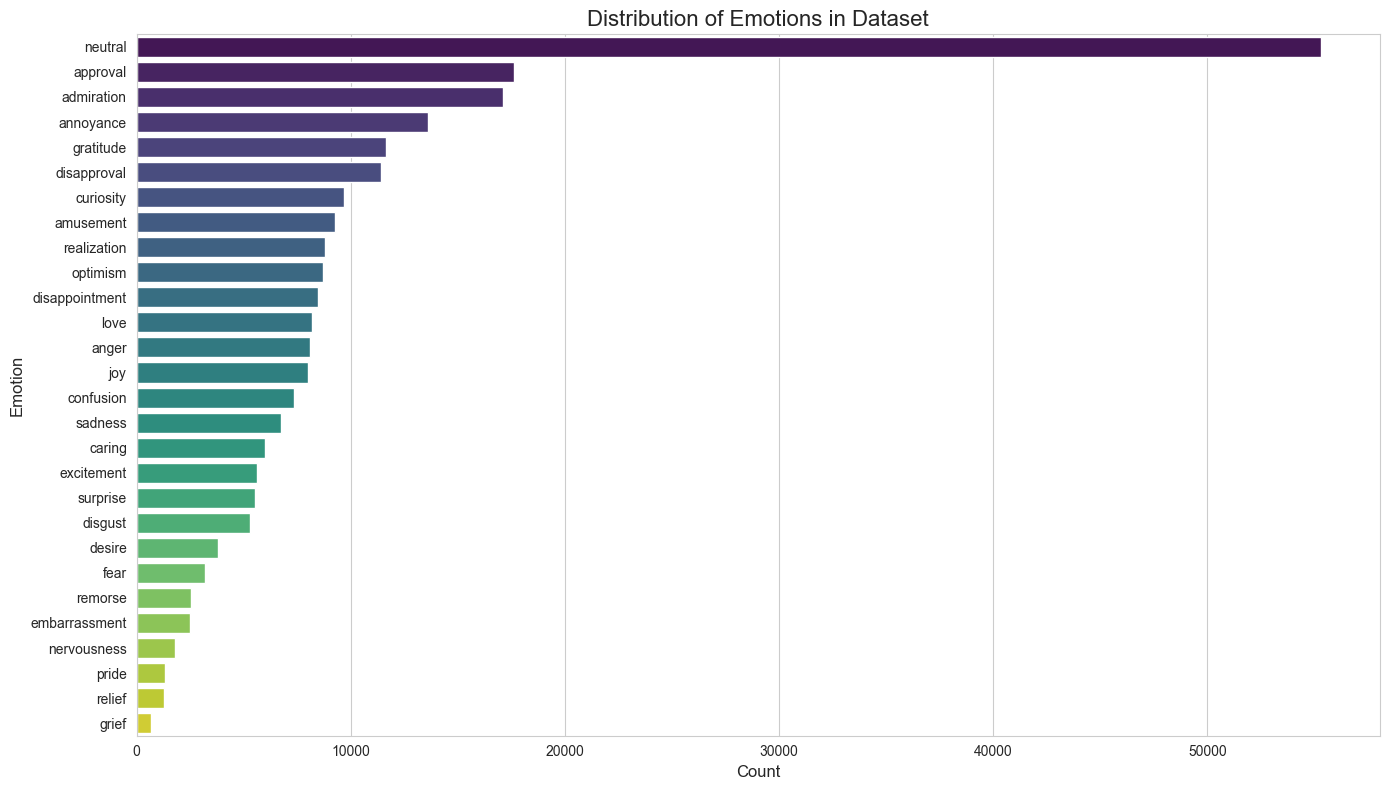

Emotion Counts (sorted by frequency):
neutral           55298
approval          17620
admiration        17131
annoyance         13618
gratitude         11625
disapproval       11424
curiosity          9692
amusement          9245
realization        8785
optimism           8715
disappointment     8469
love               8191
anger              8084
joy                7983
confusion          7359
sadness            6758
caring             5999
excitement         5629
surprise           5514
disgust            5301
desire             3817
fear               3197
remorse            2525
embarrassment      2476
nervousness        1810
pride              1302
relief             1289
grief               673
dtype: int64


In [27]:
# Count the frequency of each emotion in the dataset
emotion_counts = df[emotion_columns].sum().sort_values(ascending=False)

# Create bar plot showing emotion distribution
plt.figure(figsize=(14, 8))
sns.barplot(x=emotion_counts.values, y=emotion_counts.index, palette='viridis')
plt.title('Distribution of Emotions in Dataset', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Emotion', fontsize=12)
plt.tight_layout()
plt.savefig('emotion_distribution.png')
plt.show()

print("Emotion Counts (sorted by frequency):")
print(emotion_counts)

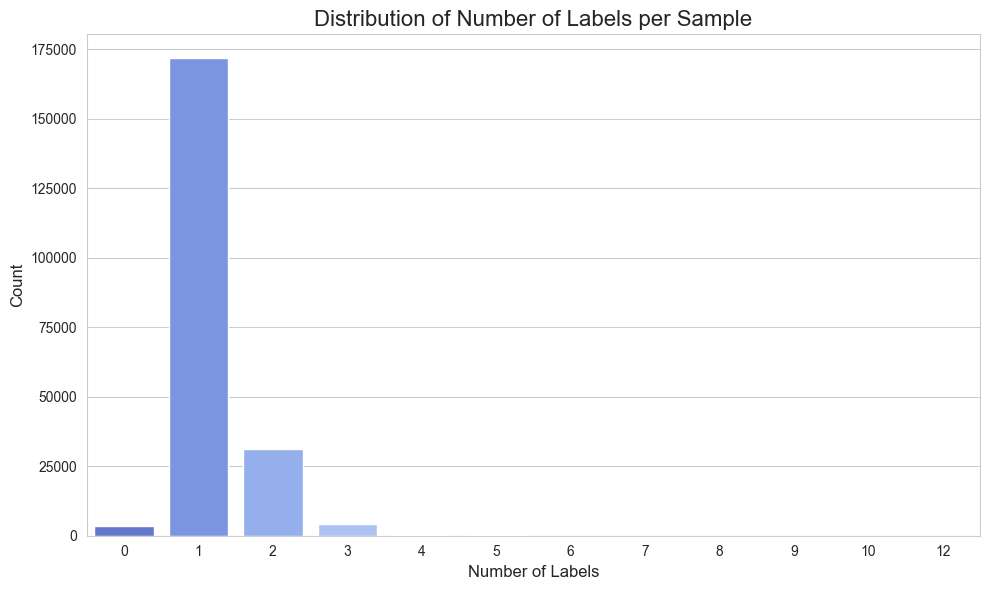

Label Count Distribution:
label_count
0       3411
1     171820
2      31187
3       4218
4        399
5        106
6         53
7         20
8          6
9          3
10         1
12         1
Name: count, dtype: int64


In [28]:
# Calculate number of labels per sample (multi-label nature)
df['label_count'] = df[emotion_columns].sum(axis=1)

# Plot distribution of label counts
plt.figure(figsize=(10, 6))
label_dist = df['label_count'].value_counts().sort_index()
sns.barplot(x=label_dist.index, y=label_dist.values, palette='coolwarm')
plt.title('Distribution of Number of Labels per Sample', fontsize=16)
plt.xlabel('Number of Labels', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('label_count_distribution.png')
plt.show()

print("Label Count Distribution:")
print(label_dist)

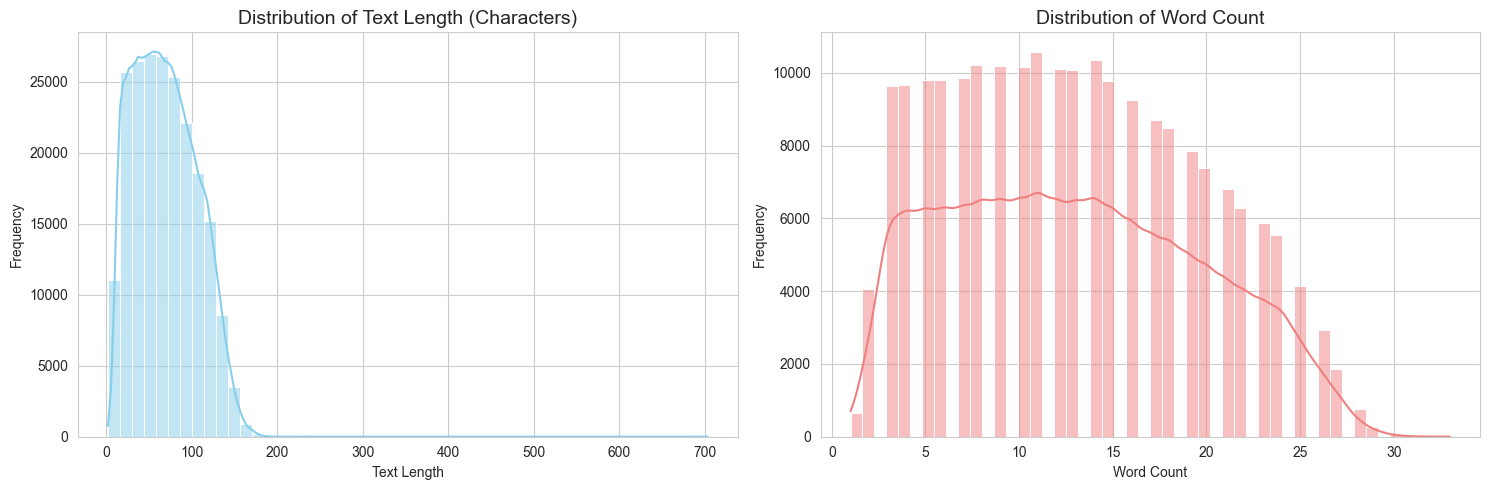

Average text length: 69.30 characters
Average word count: 13.00 words


In [29]:
# Text length analysis - helps understand the text data characteristics
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Create subplots for text analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Text length distribution
sns.histplot(df['text_length'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Text Length (Characters)', fontsize=14)
axes[0].set_xlabel('Text Length')
axes[0].set_ylabel('Frequency')

# Word count distribution
sns.histplot(df['word_count'], bins=50, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Word Count', fontsize=14)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('text_analysis.png')
plt.show()

print(f"Average text length: {df['text_length'].mean():.2f} characters")
print(f"Average word count: {df['word_count'].mean():.2f} words")

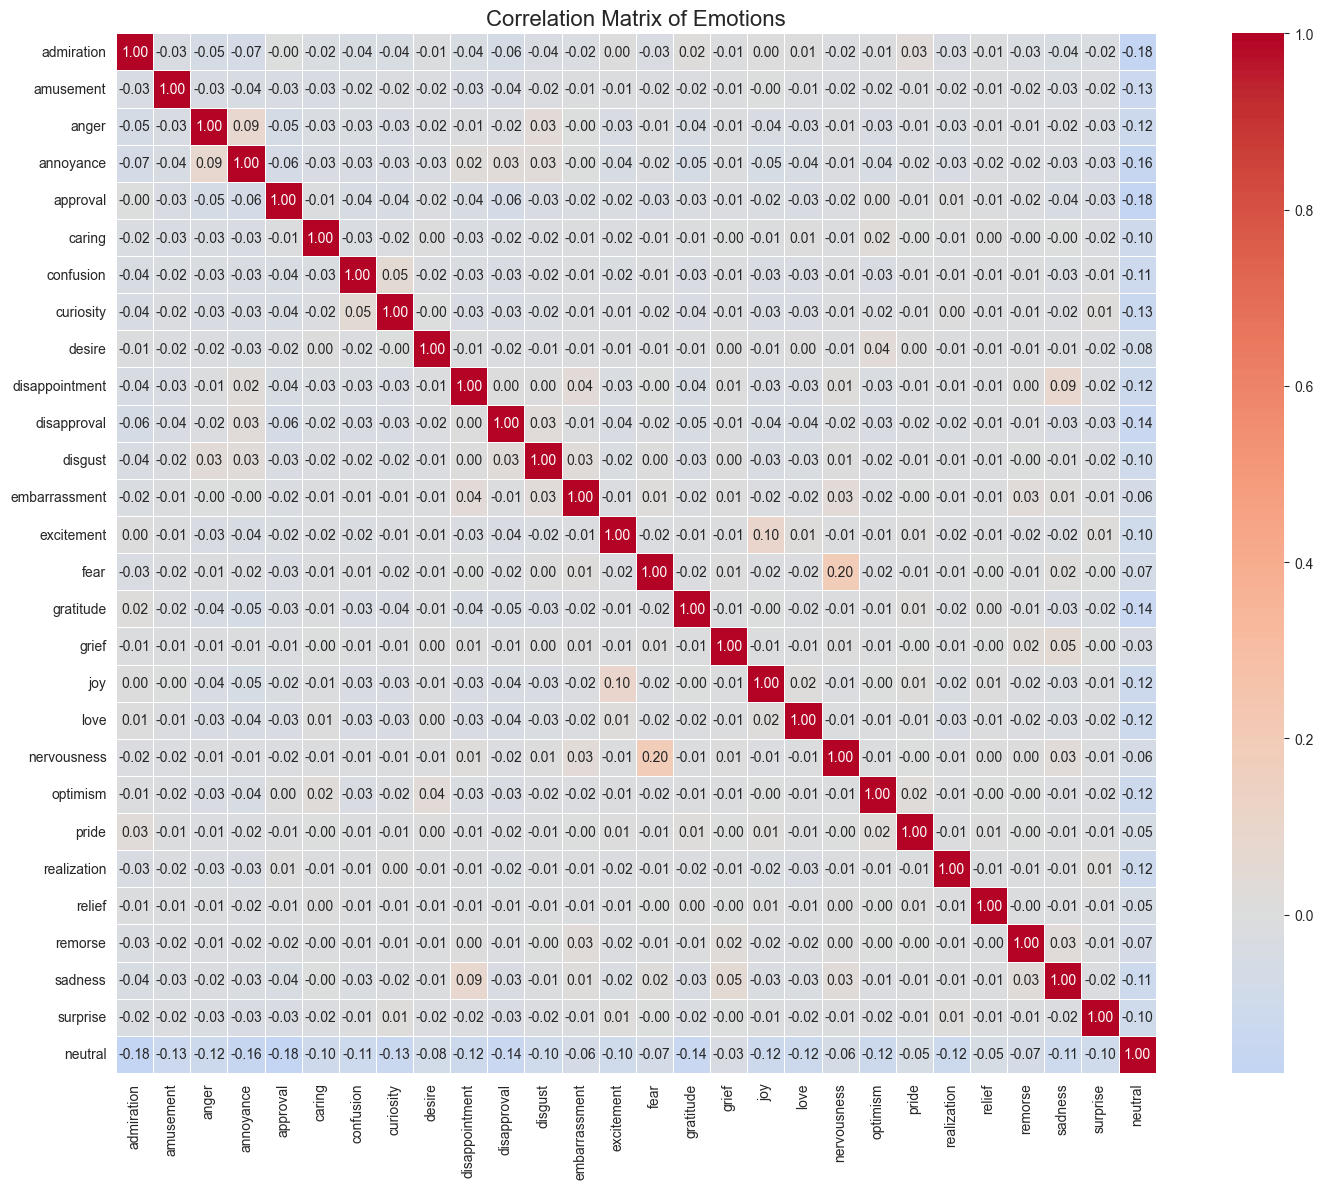

In [30]:
# Correlation heatmap - shows relationships between emotions
# This helps understand which emotions tend to appear together
plt.figure(figsize=(16, 12))
correlation_matrix = df[emotion_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Emotions', fontsize=16)
plt.tight_layout()
plt.savefig('emotion_correlation.png')
plt.show()

In [31]:
# Data cleaning - remove unclear examples and samples with no labels
# This improves data quality for model training
print(f"Original dataset size: {len(df)}")

# Remove unclear examples (where raters couldn't agree on emotions)
df_clean = df[df['example_very_unclear'] == False].copy()
print(f"After removing unclear examples: {len(df_clean)}")

# Remove samples with no emotion labels
df_clean = df_clean[df_clean['label_count'] > 0].copy()
print(f"After removing samples with no labels: {len(df_clean)}")

print(f"\nFinal dataset ready for training: {len(df_clean)} samples")

Original dataset size: 211225
After removing unclear examples: 207814
After removing samples with no labels: 207814

Final dataset ready for training: 207814 samples


---
# STEP 4: Data Preprocessing

**Why this step is needed:**
- **Train/Test Split**: Separates data for training (80%) and testing (20%) to evaluate model performance on unseen data
- **TF-IDF Vectorization**: Converts text into numerical features that machine learning models can understand
  - TF (Term Frequency): How often a word appears in a document
  - IDF (Inverse Document Frequency): Downweights common words that appear in many documents
  - Using unigrams and bigrams captures both single words and word pairs
  - Limiting features (10,000) reduces dimensionality and computational cost

In [32]:
# Prepare features (X) and labels (y)
# X = text data (input)
# y = emotion labels (target/output)
X = df_clean['text'].astype(str)
y = df_clean[emotion_columns].values

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nExample text:")
print(X.iloc[0])
print(f"\nCorresponding labels: {y[0]}")

Features shape: (207814,)
Labels shape: (207814, 28)

Example text:
That game hurt.

Corresponding labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [33]:
# Split data into training and testing sets
# test_size=0.2 means 20% of data is reserved for testing
# random_state=42 ensures reproducibility (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print(f"\nTraining percentage: {len(X_train)/len(X)*100:.1f}%")
print(f"Test percentage: {len(X_test)/len(X)*100:.1f}%")

Training set size: 166251 samples
Test set size: 41563 samples

Training percentage: 80.0%
Test percentage: 20.0%


In [34]:
# TF-IDF Vectorization - convert text to numerical features
# IMPROVED PARAMETERS for better performance
tfidf = TfidfVectorizer(
    max_features=15000,      # INCREASED from 10000 - captures more features
    stop_words='english',    # Remove common English words (the, and, is, etc.)
    ngram_range=(1, 3),      # IMPROVED: Use unigrams, bigrams, and trigrams for better context
    min_df=1,                # IMPROVED: Lower threshold to capture rare meaningful patterns
    max_df=0.98,             # IMPROVED: Slightly lower to avoid common words
    sublinear_tf=True,       # NEW: Better weighting for term frequency
    strip_accents='unicode'  # NEW: Handle accented characters
)

# Fit on training data and transform both training and test data
print("Fitting improved TF-IDF vectorizer on training data...")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF training features shape: {X_train_tfidf.shape}")
print(f"TF-IDF test features shape: {X_test_tfidf.shape}")
print(f"\nVocabulary size: {len(tfidf.get_feature_names_out())}")
print("✓ Improved TF-IDF with trigrams and better parameters!")

Fitting improved TF-IDF vectorizer on training data...

TF-IDF training features shape: (166251, 15000)
TF-IDF test features shape: (41563, 15000)

Vocabulary size: 15000
✓ Improved TF-IDF with trigrams and better parameters!



# STRATEGY 1: HANDLE CLASS IMBALANCE WITH SAMPLE WEIGHTS

**Why this step is needed:**
- Some emotions are rare in the dataset (e.g., grief, pride)
- Models tend to ignore rare emotions
- Sample weights penalize the model for misclassifying rare emotions
- This significantly improves F1 scores for underrepresented emotions


In [35]:
# Compute sample weights to handle class imbalance
from sklearn.utils.class_weight import compute_sample_weight

print("Computing sample weights for class imbalance...")

# Calculate weights for each sample (penalize rare emotions)
# For multi-label, we compute weights based on average label rarity
sample_weights = np.zeros(len(y_train))
for i in range(len(y_train)):
    # Sum of weights for emotions present in this sample
    weight_sum = 0
    emotion_count = np.sum(y_train[i])
    if emotion_count > 0:
        for j in range(len(y_train[i])):
            if y_train[i, j] == 1:
                # Weight based on rarity of this emotion
                emotion_freq = np.sum(y_train[:, j])
                weight_sum += 1.0 / emotion_freq
        sample_weights[i] = weight_sum / emotion_count
    else:
        sample_weights[i] = 1.0

# Normalize weights
sample_weights = sample_weights / np.mean(sample_weights)

print(f"✓ Sample weights computed!")
print(f"Weight range: {sample_weights.min():.4f} to {sample_weights.max():.4f}")
print(f"Mean weight: {sample_weights.mean():.4f}")
print("Samples with rare emotions will get higher weights during training.")

Computing sample weights for class imbalance...
✓ Sample weights computed!
Weight range: 0.1709 to 14.0943
Mean weight: 1.0000
Samples with rare emotions will get higher weights during training.


---
# STEP 5: Train a Random Forest Model

**Why this step is needed:**
- **Random Forest**: An ensemble learning method that builds multiple decision trees and combines their predictions
  - Reduces overfitting compared to single decision trees
  - Handles high-dimensional data well (like TF-IDF features)
  - Provides feature importance scores
- **MultiOutputClassifier**: Wraps the Random Forest to handle multi-label classification
  - Each emotion is treated as a separate binary classification problem
  - Allows predicting multiple emotions simultaneously
- **Parameters**:
  - `n_estimators=100`: Number of trees (more trees = better performance but slower)
  - `max_depth=20`: Limits tree depth to prevent overfitting
  - `class_weight='balanced'`: Handles imbalanced emotion classes

In [36]:
# Create Random Forest classifier wrapped in MultiOutputClassifier
# MultiOutputClassifier allows predicting multiple labels simultaneously
rf_classifier = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=100,        # Number of trees in the forest
        max_depth=20,            # Maximum depth of each tree
        min_samples_split=5,     # Minimum samples required to split a node
        min_samples_leaf=2,      # Minimum samples at leaf node
        random_state=42,         # For reproducibility
        n_jobs=-1,               # Use all CPU cores for faster training
        class_weight='balanced'  # Handle imbalanced classes automatically
    )
)

print("Random Forest model created!")
print("\nModel parameters:")
print(f"- Number of estimators: 100")
print(f"- Max depth: 20")
print(f"- Class weight: balanced")
print(f"- Number of emotion labels: {len(emotion_columns)}")

Random Forest model created!

Model parameters:
- Number of estimators: 100
- Max depth: 20
- Class weight: balanced
- Number of emotion labels: 28


In [37]:
# Train the model on the training data
# This step learns patterns between text features and emotion labels
print("Training Random Forest model with sample weights...")
print("This may take a few minutes depending on your system...")
print("\nTraining started...")

# Train with sample weights to handle class imbalance
# Each emotion classifier gets weighted by sample importance
rf_classifier.fit(X_train_tfidf, y_train, sample_weight=sample_weights)

print("\nTraining completed successfully!")
print("✓ Model trained with class-imbalance handling!")

Training Random Forest model with sample weights...
This may take a few minutes depending on your system...

Training started...

Training completed successfully!
✓ Model trained with class-imbalance handling!


---
# STEP 6: Evaluate and Display Metrics

**Why this step is needed:**
- **Hamming Loss**: Measures the fraction of wrong labels to total labels (lower is better)
- **F1 Score**: Harmonic mean of precision and recall (balances both metrics)
  - Micro: Aggregates contributions of all classes (good for imbalanced data)
  - Macro: Average of per-class F1 scores (treats all classes equally)
  - Weighted: Macro average weighted by support (accounts for class imbalance)
- **Exact Match Ratio**: Percentage of samples where ALL predicted labels match exactly
- **Per-emotion metrics**: Shows which emotions the model predicts well/poorly

In [38]:
# Make predictions on the test set
print("Making predictions on test set...")
y_pred = rf_classifier.predict(X_test_tfidf)

print(f"Predictions shape: {y_pred.shape}")
print("\nPredictions completed!")

Making predictions on test set...
Predictions shape: (41563, 28)

Predictions completed!


In [39]:
# Calculate overall evaluation metrics
print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)

# Hamming Loss: fraction of incorrect labels (lower is better)
hl = hamming_loss(y_test, y_pred)
print(f"\n1. Hamming Loss: {hl:.4f}")
print("   (Fraction of wrong labels to total labels - lower is better)")

# Micro F1: Aggregates all predictions globally
micro_f1 = f1_score(y_test, y_pred, average='micro')
print(f"\n2. Micro F1 Score: {micro_f1:.4f}")
print("   (Good for imbalanced datasets)")

# Macro F1: Average of per-class F1 scores
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"\n3. Macro F1 Score: {macro_f1:.4f}")
print("   (Treats all emotions equally)")

# Weighted F1: Macro F1 weighted by support
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f"\n4. Weighted F1 Score: {weighted_f1:.4f}")
print("   (Accounts for class imbalance)")

# Exact Match Ratio: samples where all labels match
exact_match = np.all(y_test == y_pred, axis=1).mean()
print(f"\n5. Exact Match Ratio: {exact_match:.4f}")
print("   (Samples where ALL emotions predicted correctly)")

MODEL EVALUATION RESULTS

1. Hamming Loss: 0.6820
   (Fraction of wrong labels to total labels - lower is better)

2. Micro F1 Score: 0.0620
   (Good for imbalanced datasets)

3. Macro F1 Score: 0.1102
   (Treats all emotions equally)

4. Weighted F1 Score: 0.1207
   (Accounts for class imbalance)

5. Exact Match Ratio: 0.0000
   (Samples where ALL emotions predicted correctly)


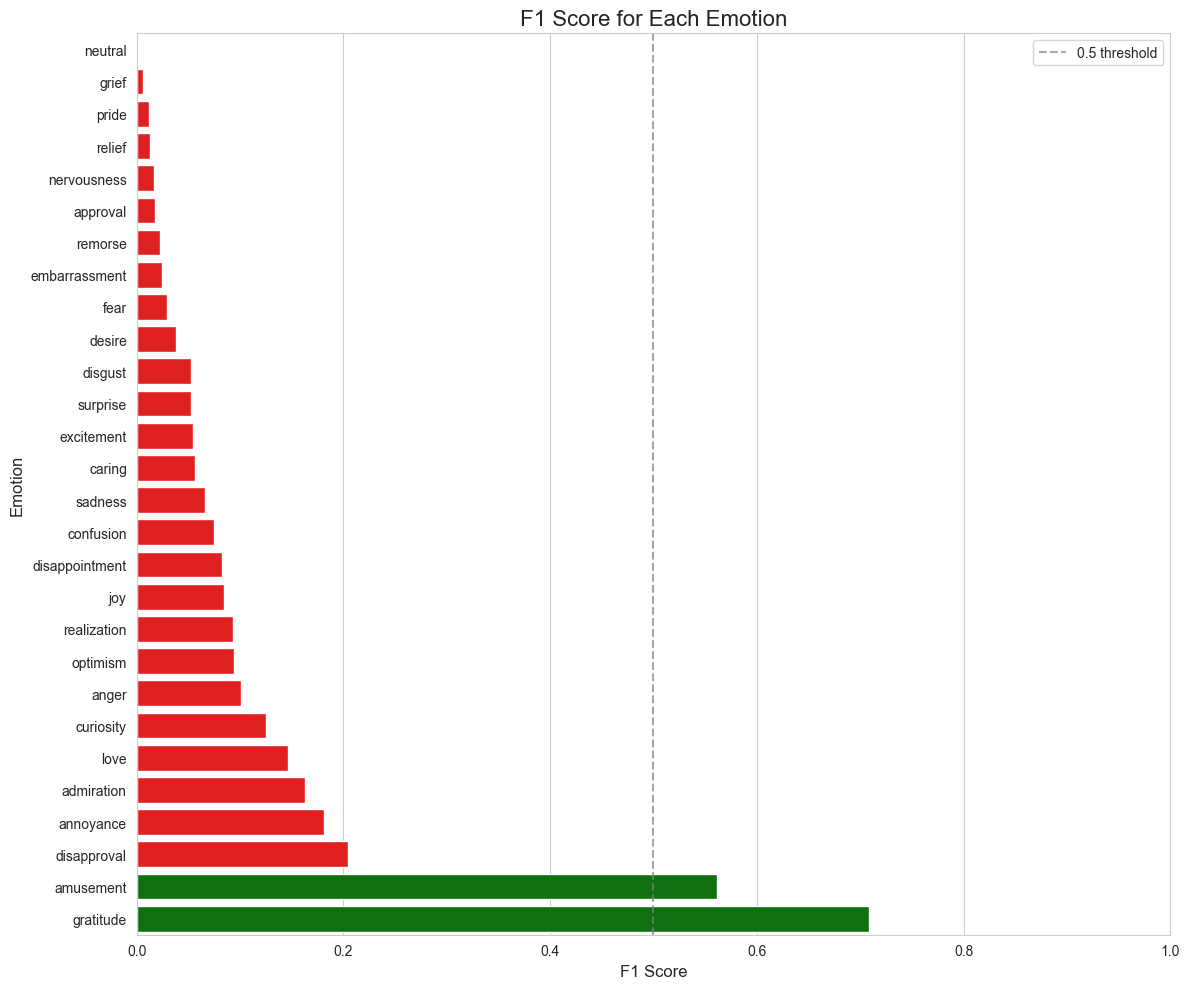

F1 Scores by Emotion (sorted from highest to lowest):
       Emotion  F1_Score
     gratitude  0.708075
     amusement  0.561142
   disapproval  0.204498
     annoyance  0.181351
    admiration  0.163192
          love  0.146565
     curiosity  0.125469
         anger  0.101131
      optimism  0.094170
   realization  0.093364
           joy  0.084680
disappointment  0.082867
     confusion  0.075185
       sadness  0.066004
        caring  0.056512
    excitement  0.054486
      surprise  0.052423
       disgust  0.052271
        desire  0.038118
          fear  0.029648
 embarrassment  0.024768
       remorse  0.022652
      approval  0.017758
   nervousness  0.017090
        relief  0.012957
         pride  0.012339
         grief  0.006476
       neutral  0.000000


In [40]:
# Calculate F1 score for each emotion individually
emotion_f1_scores = []
for i, emotion in enumerate(emotion_columns):
    f1 = f1_score(y_test[:, i], y_pred[:, i], zero_division=0)
    emotion_f1_scores.append(f1)

# Create DataFrame for visualization
f1_df = pd.DataFrame({
    'Emotion': emotion_columns,
    'F1_Score': emotion_f1_scores
}).sort_values('F1_Score', ascending=True)

# Plot F1 scores for each emotion
plt.figure(figsize=(12, 10))
colors = ['red' if x < 0.3 else 'orange' if x < 0.5 else 'green' for x in f1_df['F1_Score']]
sns.barplot(x='F1_Score', y='Emotion', data=f1_df, palette=colors)
plt.title('F1 Score for Each Emotion', fontsize=16)
plt.xlabel('F1 Score', fontsize=12)
plt.ylabel('Emotion', fontsize=12)
plt.xlim(0, 1)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='0.5 threshold')
plt.legend()
plt.tight_layout()
plt.savefig('f1_scores_by_emotion.png')
plt.show()

# Display F1 scores sorted by performance
print("F1 Scores by Emotion (sorted from highest to lowest):")
print(f1_df.sort_values('F1_Score', ascending=False).to_string(index=False))

---
# STRATEGY 5: THRESHOLD TUNING FOR BETTER PREDICTIONS

**Why this step is needed:**
- By default, predictions use 0.5 probability threshold
- For multi-label problems, lower thresholds (0.3-0.4) often work better
- Tuning the threshold can improve F1 scores significantly
- Different thresholds work better for different emotions


In [42]:
# Threshold Tuning - Find optimal threshold for each emotion
from sklearn.metrics import precision_recall_curve

print("=" * 60)
print("THRESHOLD TUNING - Testing different decision thresholds")
print("=" * 60)

# Get prediction probabilities instead of binary predictions
# MultiOutputClassifier returns list of probability arrays, convert to numpy array
y_pred_proba_list = rf_classifier.predict_proba(X_test_tfidf)
# Extract the positive class probability (second column of each classifier)
y_pred_proba = np.column_stack([proba[:, 1] for proba in y_pred_proba_list])

print(f"Probability array shape: {y_pred_proba.shape}")

# Test different thresholds
thresholds_to_test = [0.2, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
threshold_results = []

for threshold in thresholds_to_test:
    # Convert probabilities to predictions using custom threshold
    y_pred_custom = (y_pred_proba > threshold).astype(int)
    
    # Calculate metrics
    f1_micro = f1_score(y_test, y_pred_custom, average='micro')
    f1_macro = f1_score(y_test, y_pred_custom, average='macro')
    f1_weighted = f1_score(y_test, y_pred_custom, average='weighted')
    hl = hamming_loss(y_test, y_pred_custom)
    
    threshold_results.append({
        'threshold': threshold,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'hamming_loss': hl
    })
    
    print(f"\nThreshold: {threshold:.2f}")
    print(f"  Micro F1: {f1_micro:.4f} | Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f}")
    print(f"  Hamming Loss: {hl:.4f}")

# Find best threshold
threshold_df = pd.DataFrame(threshold_results)
best_idx = threshold_df['f1_weighted'].idxmax()
best_threshold = threshold_df.loc[best_idx, 'threshold']
best_f1 = threshold_df.loc[best_idx, 'f1_weighted']

print("\n" + "=" * 60)
print(f"✓ BEST THRESHOLD: {best_threshold:.2f}")
print(f"  Weighted F1 Score: {best_f1:.4f}")
print(f"  Improvement: +{(best_f1 - weighted_f1):.4f}")
print("=" * 60)

# Apply best threshold
y_pred_optimized = (y_pred_proba > best_threshold).astype(int)

# Show comparison
print("\nCOMPARISON: Default vs Optimized Threshold")
print("-" * 60)
print(f"{'Metric':<20} {'Default (0.5)':<20} {'Optimized ({:.2f})':<20}".format(best_threshold))
print("-" * 60)
print(f"{'Weighted F1':<20} {weighted_f1:<20.4f} {threshold_df.loc[best_idx, 'f1_weighted']:<20.4f}")
print(f"{'Macro F1':<20} {macro_f1:<20.4f} {threshold_df.loc[best_idx, 'f1_macro']:<20.4f}")
print(f"{'Micro F1':<20} {micro_f1:<20.4f} {threshold_df.loc[best_idx, 'f1_micro']:<20.4f}")
print(f"{'Hamming Loss':<20} {hl:<20.4f} {threshold_df.loc[best_idx, 'hamming_loss']:<20.4f}")

THRESHOLD TUNING - Testing different decision thresholds
Probability array shape: (41563, 28)

Threshold: 0.20
  Micro F1: 0.0668 | Macro F1: 0.0644 | Weighted F1: 0.0720
  Hamming Loss: 0.9400

Threshold: 0.30
  Micro F1: 0.0668 | Macro F1: 0.0642 | Weighted F1: 0.0710
  Hamming Loss: 0.9400

Threshold: 0.35
  Micro F1: 0.0669 | Macro F1: 0.0646 | Weighted F1: 0.0717
  Hamming Loss: 0.9370

Threshold: 0.40
  Micro F1: 0.0657 | Macro F1: 0.0777 | Weighted F1: 0.0965
  Hamming Loss: 0.8787

Threshold: 0.45
  Micro F1: 0.0636 | Macro F1: 0.0971 | Weighted F1: 0.1202
  Hamming Loss: 0.8027

Threshold: 0.50
  Micro F1: 0.0620 | Macro F1: 0.1102 | Weighted F1: 0.1207
  Hamming Loss: 0.6820

Threshold: 0.55
  Micro F1: 0.0579 | Macro F1: 0.1407 | Weighted F1: 0.1374
  Hamming Loss: 0.4901

Threshold: 0.60
  Micro F1: 0.0451 | Macro F1: 0.0995 | Weighted F1: 0.0871
  Hamming Loss: 0.3838

✓ BEST THRESHOLD: 0.55
  Weighted F1 Score: 0.1374
  Improvement: +0.0167

COMPARISON: Default vs Optimiz

In [43]:
# Display detailed classification report for each emotion
print("=" * 50)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 50)

# Show reports for emotions with F1 score > 0.4 (better performing)
print("\n--- EMOTIONS WITH F1 SCORE > 0.4 (Better Performance) ---")
for i, emotion in enumerate(emotion_columns):
    f1 = f1_score(y_test[:, i], y_pred[:, i], zero_division=0)
    if f1 > 0.4:
        print(f"\n{emotion.upper()} (F1: {f1:.3f})")
        print(classification_report(y_test[:, i], y_pred[:, i], 
                                    target_names=['Not ' + emotion, emotion], 
                                    zero_division=0))

DETAILED CLASSIFICATION REPORTS

--- EMOTIONS WITH F1 SCORE > 0.4 (Better Performance) ---

AMUSEMENT (F1: 0.561)
               precision    recall  f1-score   support

Not amusement       0.99      0.95      0.97     39778
    amusement       0.44      0.78      0.56      1785

     accuracy                           0.95     41563
    macro avg       0.71      0.87      0.77     41563
 weighted avg       0.97      0.95      0.95     41563


GRATITUDE (F1: 0.708)
               precision    recall  f1-score   support

Not gratitude       0.98      0.99      0.98     39240
    gratitude       0.80      0.64      0.71      2323

     accuracy                           0.97     41563
    macro avg       0.89      0.81      0.85     41563
 weighted avg       0.97      0.97      0.97     41563



---
# STRATEGY 3: COMPARE WITH GRADIENT BOOSTING MODEL

**Why this step is needed:**
- Gradient Boosting often outperforms Random Forest on complex datasets
- Builds trees sequentially, correcting previous mistakes
- Better for multi-label classification problems
- Can achieve higher F1 scores on difficult emotions


In [44]:
# Train Gradient Boosting as alternative model
from sklearn.ensemble import GradientBoostingClassifier

print("=" * 60)
print("TRAINING GRADIENT BOOSTING MODEL (Alternative to Random Forest)")
print("=" * 60)

# Create Gradient Boosting classifier
gb_classifier = MultiOutputClassifier(
    GradientBoostingClassifier(
        n_estimators=150,        # More trees for sequential learning
        learning_rate=0.1,       # How much each tree contributes
        max_depth=5,             # Shallower trees to prevent overfitting
        subsample=0.8,           # Use 80% of samples for each tree
        random_state=42,
        verbose=0
    )
)

print("Training Gradient Boosting model...")
print("This may take several minutes...\n")

# Train with sample weights (same weights as Random Forest)
gb_classifier.fit(X_train_tfidf, y_train, sample_weight=sample_weights)

print("✓ Gradient Boosting training completed!")

# Make predictions
y_pred_gb = gb_classifier.predict(X_test_tfidf)

# Evaluate
print("\n" + "=" * 60)
print("GRADIENT BOOSTING EVALUATION RESULTS")
print("=" * 60)

gb_micro_f1 = f1_score(y_test, y_pred_gb, average='micro')
gb_macro_f1 = f1_score(y_test, y_pred_gb, average='macro')
gb_weighted_f1 = f1_score(y_test, y_pred_gb, average='weighted')
gb_hl = hamming_loss(y_test, y_pred_gb)

print(f"\n1. Micro F1 Score: {gb_micro_f1:.4f} (RF: {micro_f1:.4f}) Δ {gb_micro_f1-micro_f1:+.4f}")
print(f"2. Macro F1 Score: {gb_macro_f1:.4f} (RF: {macro_f1:.4f}) Δ {gb_macro_f1-macro_f1:+.4f}")
print(f"3. Weighted F1 Score: {gb_weighted_f1:.4f} (RF: {weighted_f1:.4f}) Δ {gb_weighted_f1-weighted_f1:+.4f}")
print(f"4. Hamming Loss: {gb_hl:.4f} (RF: {hl:.4f}) Δ {gb_hl-hl:+.4f}")

# Determine better model
if gb_weighted_f1 > weighted_f1:
    print(f"\n✓ GRADIENT BOOSTING IS BETTER (F1 improvement: {(gb_weighted_f1-weighted_f1)*100:.2f}%)")
else:
    print(f"\n✓ RANDOM FOREST IS BETTER (F1 difference: {(weighted_f1-gb_weighted_f1)*100:.2f}%)")

print("=" * 60)

TRAINING GRADIENT BOOSTING MODEL (Alternative to Random Forest)
Training Gradient Boosting model...
This may take several minutes...

✓ Gradient Boosting training completed!

GRADIENT BOOSTING EVALUATION RESULTS

1. Micro F1 Score: 0.2377 (RF: 0.0620) Δ +0.1757
2. Macro F1 Score: 0.2318 (RF: 0.1102) Δ +0.1217
3. Weighted F1 Score: 0.1862 (RF: 0.1207) Δ +0.0654
4. Hamming Loss: 0.0415 (RF: 0.3838) Δ -0.3422

✓ GRADIENT BOOSTING IS BETTER (F1 improvement: 6.54%)


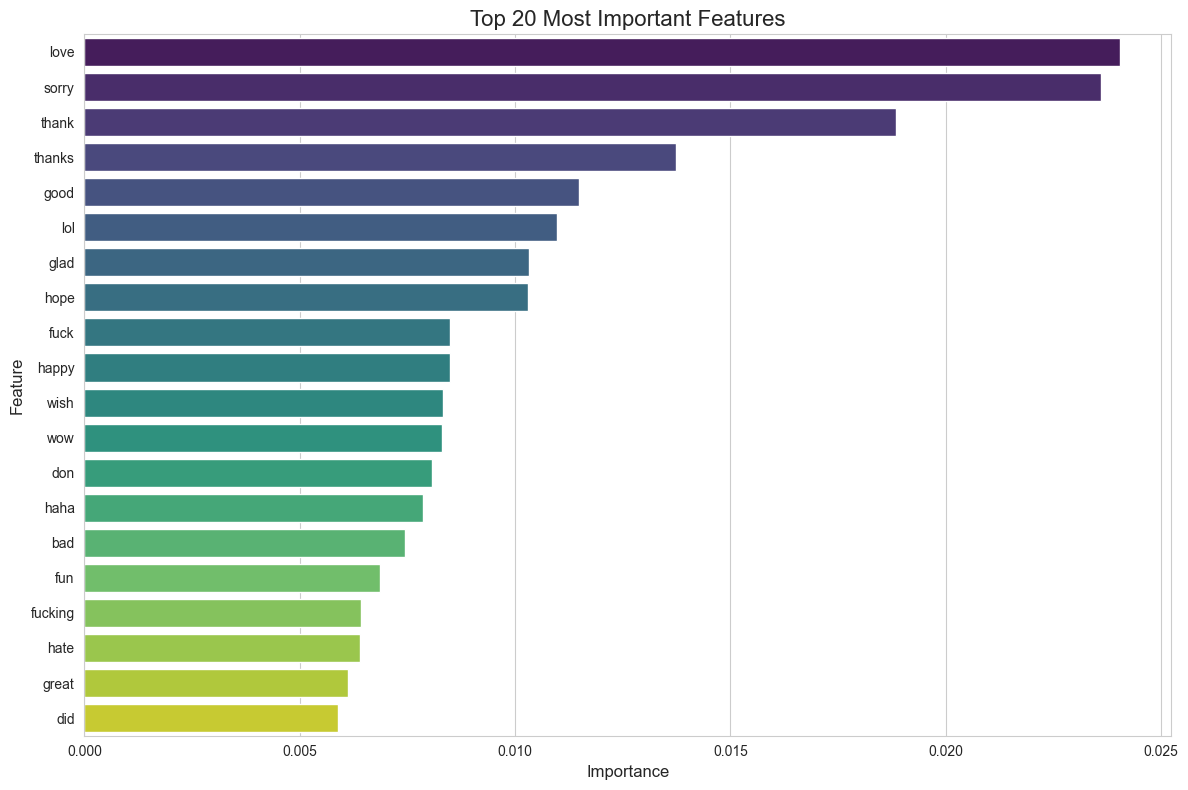

Top 20 Most Important Features:
feature  importance
   love    0.024036
  sorry    0.023601
  thank    0.018843
 thanks    0.013737
   good    0.011480
    lol    0.010973
   glad    0.010316
   hope    0.010311
   fuck    0.008489
  happy    0.008486
   wish    0.008325
    wow    0.008294
    don    0.008081
   haha    0.007873
    bad    0.007433
    fun    0.006854
fucking    0.006417
   hate    0.006394
  great    0.006120
    did    0.005894


In [45]:
# Feature importance analysis - shows which words are most important for predictions
# Average feature importance across all emotion classifiers
feature_importances = np.mean([
    estimator.feature_importances_ 
    for estimator in rf_classifier.estimators_
], axis=0)

# Get feature names from TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Create DataFrame of features and their importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

# Plot top 20 most important features
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
sns.barplot(x='importance', y='feature', data=top_features, palette='viridis')
plt.title('Top 20 Most Important Features', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('top_features.png')
plt.show()

print("Top 20 Most Important Features:")
print(top_features.to_string(index=False))

---
# STEP 7: Test with Sample Predictions

**Why this step is needed:**
- Validates that the model works on new, unseen text examples
- Demonstrates how the model performs on different types of emotional content
- Shows practical usage of the trained model
- Helps identify if the model is making sensible predictions

In [46]:
# Function to predict emotions for new text input
def predict_emotions(text, model, vectorizer, emotion_labels):
    """
    Predict emotions for a given text.
    
    Parameters:
    - text: Input text string
    - model: Trained classifier
    - vectorizer: TF-IDF vectorizer
    - emotion_labels: List of emotion names
    
    Returns:
    - List of predicted emotions
    """
    # Convert text to TF-IDF features
    text_tfidf = vectorizer.transform([text])
    
    # Make prediction
    prediction = model.predict(text_tfidf)[0]
    
    # Get emotion names where prediction is 1
    predicted_emotions = [emotion_labels[i] for i, pred in enumerate(prediction) if pred == 1]
    
    return predicted_emotions

print("Prediction function created!")

Prediction function created!


In [47]:
# Test with sample texts covering different emotions
sample_texts = [
    "I am so happy today! This is the best day of my life.",
    "I am really angry about what happened at work.",
    "Thank you so much for your help, I really appreciate it.",
    "I am scared and nervous about the upcoming exam.",
    "This movie was hilarious, I couldn't stop laughing!",
    "I am so sad and disappointed by the news.",
    "Wow! I can't believe this is happening!"
]

print("=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

for i, text in enumerate(sample_texts, 1):
    predicted = predict_emotions(text, rf_classifier, tfidf, emotion_columns)
    print(f"\n{i}. Text: {text}")
    print(f"   Predicted Emotions: {predicted if predicted else 'None detected'}")
    print("-" * 60)

SAMPLE PREDICTIONS

1. Text: I am so happy today! This is the best day of my life.
   Predicted Emotions: ['caring', 'desire', 'disappointment', 'embarrassment', 'excitement', 'fear', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'relief', 'remorse', 'sadness', 'surprise']
------------------------------------------------------------

2. Text: I am really angry about what happened at work.
   Predicted Emotions: ['anger', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disgust', 'embarrassment', 'excitement', 'fear', 'grief', 'joy', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise']
------------------------------------------------------------

3. Text: Thank you so much for your help, I really appreciate it.
   Predicted Emotions: ['caring', 'desire', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'nervousness', 'optimism', 'pride', 'relief', 'remorse', 'sadness', 'surprise']
----------------

---
# STEP 8: Save the Trained Model Files

**Why this step is needed:**
- **Model persistence**: Save the trained model so you don't need to retrain every time
- **Reuse**: Load the model later for predictions without retraining
- **Deployment**: Use the saved model in applications or web services
- **Three files are saved**:
  - `random_forest_emotion_model.pkl`: The trained Random Forest classifier
  - `tfidf_vectorizer.pkl`: The TF-IDF vectorizer (needed to transform new text)
  - `emotion_labels.pkl`: The list of emotion labels

In [48]:
# Save the trained model and related objects using joblib
# joblib is efficient for saving large numpy arrays and sklearn models

# Save the Random Forest model
joblib.dump(rf_classifier, 'random_forest_emotion_model.pkl')
print("Saved: random_forest_emotion_model.pkl")

# Save the TF-IDF vectorizer (needed to transform new text)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Saved: tfidf_vectorizer.pkl")

# Save the emotion labels list
joblib.dump(emotion_columns, 'emotion_labels.pkl')
print("Saved: emotion_labels.pkl")

print("\n" + "=" * 50)
print("All model files saved successfully!")
print("=" * 50)

Saved: random_forest_emotion_model.pkl
Saved: tfidf_vectorizer.pkl
Saved: emotion_labels.pkl

All model files saved successfully!


In [49]:
# Demonstrate how to load and use the saved model
print("\nDemonstrating how to load the saved model:\n")

# Load the saved model, vectorizer, and labels
loaded_model = joblib.load('random_forest_emotion_model.pkl')
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')
loaded_labels = joblib.load('emotion_labels.pkl')

print("Model loaded successfully!")
print(f"Loaded {len(loaded_labels)} emotion labels")

# Test prediction with loaded model
test_text = "I love this product, it's amazing!"
predicted_emotions = predict_emotions(test_text, loaded_model, loaded_vectorizer, loaded_labels)

print(f"\nTest text: {test_text}")
print(f"Predicted emotions: {predicted_emotions}")


Demonstrating how to load the saved model:

Model loaded successfully!
Loaded 28 emotion labels

Test text: I love this product, it's amazing!
Predicted emotions: ['admiration', 'caring', 'desire', 'disgust', 'embarrassment', 'excitement', 'fear', 'grief', 'joy', 'love', 'nervousness', 'pride', 'relief', 'remorse', 'surprise']
